# Data Explorer
PCA visualizations of model activations on true/false statement datasets.

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import configparser

from utils import collect_acts, get_pcs
from visualization_utils import TruthData

model = 'llama-2-13b'
config = configparser.ConfigParser()
config.read('../config.ini')
noperiod = config[model].get('noperiod', 'False').strip().lower() == 'true'
device = 'cuda:0' if t.cuda.is_available() else 'cpu'
layer = 12

print(f'Model: {model}  |  Layer: {layer}  |  Device: {device}')

Model: llama-2-13b  |  Layer: 12  |  Device: cpu


In [2]:
def load_dataset(name, lay=None):
    """Return (acts [n, d], labels [n], statements [n]) for a dataset."""
    lay = lay or layer
    acts = collect_acts(name, model, lay, noperiod=noperiod, center=True, device=device)
    df = pd.read_csv(f'../datasets/{name}.csv')
    n = min(acts.shape[0], len(df))
    return acts[:n], df['label'].values[:n], df['statement'].values[:n]


def pca_project(acts, k=2, pcs=None):
    """Project centered activations onto top-k PCs. Returns (coords [n,k], pcs [d,k])."""
    centered = acts - acts.mean(0)
    if pcs is None:
        pcs = get_pcs(centered, k)
    return (centered @ pcs).cpu().numpy(), pcs


def scatter_tf(ax, coords, labels, title=None, s=10, alpha=0.65):
    """Plot true/false scatter on an axes."""
    false_mask = labels == 0
    true_mask = labels == 1
    ax.scatter(coords[false_mask, 0], coords[false_mask, 1],
               c='#C44E52', s=s, alpha=alpha, label='false', rasterized=True)
    ax.scatter(coords[true_mask, 0], coords[true_mask, 1],
               c='#4C72B0', s=s, alpha=alpha, label='true', rasterized=True)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    if title:
        ax.set_title(title, fontsize=10)

---
## Multi-dataset grid
Each subplot uses its own PCA basis.

In [7]:
datasets = ['cities', 'larger_than']

td = TruthData.from_datasets(datasets, model, layer, noperiod=noperiod, device=device)

for ds in datasets:
    fig = td.plot(2, plot_datasets=[ds], pca_datasets=[ds], color='label')
    fig.update_layout(
        title=f'{ds} — PCA (layer {layer})',
        width=600, height=500,
    )
    fig.show()

---
## Layer sweep

KeyboardInterrupt: 

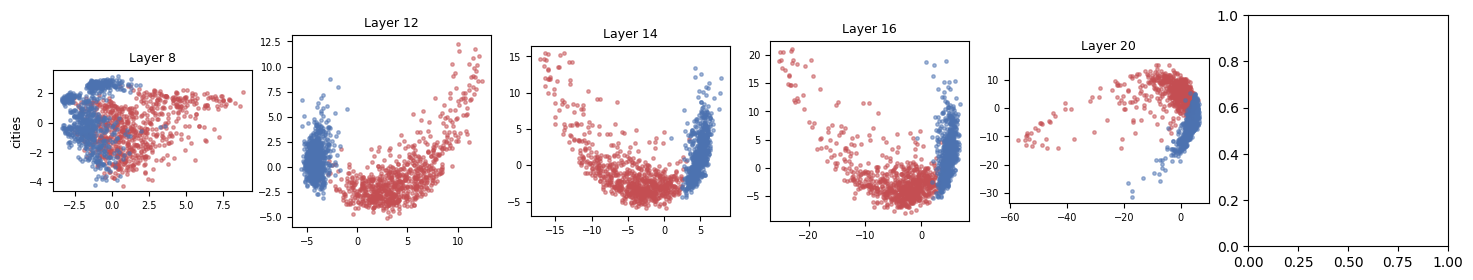

In [5]:
sweep_datasets = ['cities']
sweep_layers = [8, 12, 14, 16, 20, 24]

# keep only layers that exist on disk
sweep_layers = [l for l in sweep_layers
                if os.path.exists(os.path.join('..', 'acts', model, 'cities', f'layer_{l}_0.pt'))]
sweep_datasets = [d for d in sweep_datasets
                  if os.path.isdir(os.path.join('..', 'acts', model, d))]

if sweep_layers and sweep_datasets:
    nr, nc = len(sweep_datasets), len(sweep_layers)
    fig, axes = plt.subplots(nr, nc, figsize=(3 * nc, 3 * nr))
    axes = np.atleast_2d(axes)

    for r, ds in enumerate(sweep_datasets):
        for c, lay in enumerate(sweep_layers):
            ax = axes[r, c]
            try:
                a, lb, _ = load_dataset(ds, lay=lay)
                co, _ = pca_project(a)
                scatter_tf(ax, co, lb, s=6, alpha=0.5)
            except Exception as e:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            if r == 0:
                ax.set_title(f'Layer {lay}', fontsize=9)
            if c == 0:
                ax.set_ylabel(ds, fontsize=9)

    plt.suptitle('Truth representations across layers', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Need activations for multiple layers. See generate_acts.py.')